# 04: Integer Softmax

Standard softmax: $\text{softmax}(x_i) = e^{x_i} / \sum e^{x_j}$

Needs float exp + float division.

Int: base-2 exp (shift + LUT) + one integer division per row.

In [1]:
import pathlib
import sys

sys.path.insert(0, str(pathlib.Path("../")))

import matplotlib.pyplot as plt
import numpy as np
import torch

from smelt.plac import from_fixed, to_fixed
from smelt.softmax import softmax_int32

## base-2

$2^n$ for integer $n$ is a bit-shift: `1 << n`.

For the fractional part $f \in [0, 1)$, precompute $2^f$ in a 256-entry LUT.

So $e^x = 2^{x \cdot \log_2 e}$, and $\log_2 e \approx 1.4427$ is a fixed constant.

The full decomposition:
$$e^x = 2^{q + f} = 2^q \cdot \text{LUT}[f]$$
where $q = \lfloor x \cdot \log_2 e \rfloor$ (integer, becomes a shift) and $f$ indexes the LUT.

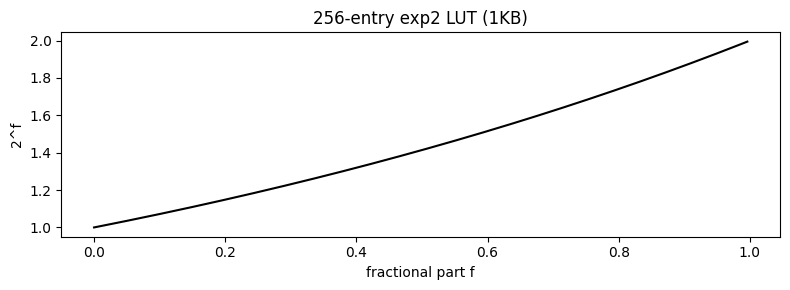

In [2]:
# base-2 exp LUT: 2^(f/256) for f in [0, 255]
lut = np.array([2 ** (i / 256) for i in range(256)])

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.arange(256) / 256, lut, "k-", lw=1.5)
ax.set_xlabel("fractional part f")
ax.set_ylabel("2^f")
ax.set_title("256-entry exp2 LUT (1KB)")
plt.tight_layout()
plt.show()

## Normalization

After finding $e_i = 2^{x_i}$ for all elements, need $e_i / \sum e_j$.

One integer division per row (not per element):
$$\text{out}_i = (e_i \ll 16) \;/\; \sum e_j$$

The shift left by 16 converts to Q16.16 before dividing.

## Correctness check

In [3]:
x_float = np.array([1.0, 2.0, 3.0, 4.0, 0.5])
x_fix = torch.from_numpy(to_fixed(x_float))

y_int = softmax_int32(x_fix)
y_float = torch.softmax(torch.tensor(x_float), dim=0).numpy()
y_int_np = from_fixed(y_int.numpy())

print(f"{'input':>8s}  {'torch':>8s}  {'smelt':>8s}  {'error':>8s}")
for i in range(len(x_float)):
    err = abs(y_float[i] - y_int_np[i])
    print(f"{x_float[i]:>8.2f}  {y_float[i]:>8.4f}  {y_int_np[i]:>8.4f}  {err:>8.4f}")
    
print(f"\nsum: torch={y_float.sum():.4f}  smelt={y_int_np.sum():.4f}")

   input     torch     smelt     error
    1.00    0.0314    0.0314    0.0000
    2.00    0.0855    0.0854    0.0000
    3.00    0.2324    0.2321    0.0003
    4.00    0.6316    0.6320    0.0003
    0.50    0.0191    0.0191    0.0000

sum: torch=1.0000  smelt=1.0000


## Accuracy over seq lengths

In [4]:
np.random.seed(42)
print(f"{'seq_len':>8s}  {'max_err':>8s}  {'sum_err':>8s}  {'argmax_ok':>10s}")
for n in [16, 64, 128, 512, 2048]:
    x = np.random.randn(n) * 3
    x_fix = torch.from_numpy(to_fixed(x))

    y_int = from_fixed(softmax_int32(x_fix).numpy())
    y_ref = torch.softmax(torch.tensor(x, dtype=torch.float64), dim=0).numpy()

    max_err = np.max(np.abs(y_int - y_ref))
    sum_err = abs(y_int.sum() - 1.0)
    argmax_ok = np.argmax(y_int) == np.argmax(y_ref)
    print(f"{n:>8d}  {max_err:>8.4f}  {sum_err:>8.4f}  {argmax_ok!s:>10s}")

 seq_len   max_err   sum_err   argmax_ok
      16    0.0005    0.0001        True
      64    0.0004    0.0005        True
     128    0.0005    0.0009        True
     512    0.0019    0.0018        True
    2048    0.0003    0.0098        True


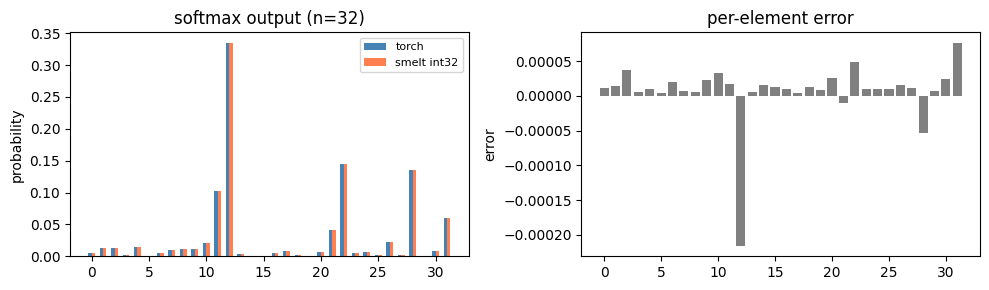

In [5]:
x = np.random.randn(32) * 3
y_ref = torch.softmax(torch.tensor(x, dtype=torch.float64), dim=0).numpy()
y_int = from_fixed(softmax_int32(torch.from_numpy(to_fixed(x))).numpy())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

ax1.bar(np.arange(32) - 0.15, y_ref, 0.3, label="torch", color="steelblue")
ax1.bar(np.arange(32) + 0.15, y_int, 0.3, label="smelt int32", color="coral")
ax1.legend(fontsize=8)
ax1.set_ylabel("probability")
ax1.set_title("softmax output (n=32)")

ax2.bar(np.arange(32), y_ref - y_int, color="gray")
ax2.set_ylabel("error")
ax2.set_title("per-element error")

plt.tight_layout()
plt.show()

## Int ops used

Per row of length n:

| step | ops | count |
|:-----|:----|------:|
| subtract max | int sub | n |
| x * log2(e) | int mul (fixed constant) | n |
| split q, f | shift + mask | n |
| 2^f LUT | array index | n |
| 2^q shift | right-shift | n |
| sum | int add | n |
| normalize | int div | 1 |
| scale outputs | shift + div | n |

One integer division for the whole row. 